# Notebook 07 - Sensitivity Analysis

The purpose of this notebook is to identify which layers, and later which MoE experts, are most sensitive to simulated low-precision weights in DeepSeek-Coder-V2-Lite-Instruct, then hand a small, evidence-backed precision policy to Notebook 08.

## Notebook structure
1. Define sensitivity analysis.
2. Establish one reusable evaluation harness.
3. Establish one reusable ablation mechanism.
4. Run one tiny smoke test to prove the machinery works.
5. Run or load one full baseline and save it.
6. Run or load one cheap all-layer screen and save it.
7. Select follow-up layers from the screen.
8. Run or load full follow-up ablations and save them.
9. Compare saved artifacts only.
10. State conclusions and hand off to Notebook 08.

## Key concepts
- **Reference run**: the unablated model under the same PyTorch HumanEval harness.
- **Candidate run**: the same model after one targeted layer is quantized and dequantized in-place.
- **Layer sensitivity**: the quality delta when every Linear module in one decoder layer is ablated.
- **Expert sensitivity**: the same idea applied inside a Mixture-of-Experts layer; this notebook starts with layer groups so Notebook 08 has a coarse policy first.
- **Sensitivity delta**: `reference_pass@1 - candidate_pass@1`; larger positive values mean the layer is more harmed by the ablation.
- **Screening run**: a cheap, noisy first pass used to choose where full evaluation time should go.
- **Follow-up run**: a full HumanEval run on a selected layer, used for the actual mixed-precision policy.

Notebook 06 handled the FP16/Q8/Q4 GGUF speed and memory story.  This notebook is about component-level sensitivity, not whole-model deployment benchmarking.

## 1. Goal

Sensitivity analysis asks a local question: if we quantize one component while holding the rest of the model constant, how much does task quality move?

In a dense transformer, the component might be a decoder layer or a projection matrix. In a Mixture-of-Experts model, it can also be a routed expert inside an MoE layer. This notebook starts with layer-level ablations because they give the quickest reliable signal for mixed precision: which blocks should stay protected, and which blocks are reasonable candidates for lower precision.

That matters because quantization error is not distributed evenly. Some layers can be pushed to lower precision with little measured quality loss. Others act like bottlenecks: a small local perturbation can cause a large task-level drop. Notebook 08 will convert the ranking from this notebook into a practical precision policy.

## 2. Setup

This section defines paths, imports, artifact names, and the experiment switch. Long-running cells are present in the notebook, but they only run when `RUN_LONG_EXPERIMENTS = True`. The interpretation cells at the end load JSON artifacts from disk, so the final conclusions do not depend on hidden in-memory variables.

In [1]:
from pathlib import Path
from IPython.display import Markdown, display
from datasets import load_dataset
from torch import nn
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer
import datetime as dt
import gc
import json
import os
import sys
import time

import matplotlib.pyplot as plt
import torch

# HumanEval executes generated code in subprocesses. Disabling tokenizer worker
# parallelism avoids fork warnings and makes runs easier to read.
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
CWD = Path.cwd().resolve()
if (CWD / "results").exists() and (CWD / "notebooks").exists():
    PROJECT_ROOT = CWD
else:
    PROJECT_ROOT = (CWD / "..").resolve()

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

MODEL_ID = "deepseek-ai/DeepSeek-Coder-V2-Lite-Instruct"
REMOTE_CODE_REVISION = "refs/pr/10"
TORCH_DTYPE = torch.bfloat16
ATTN_IMPLEMENTATION = "eager"

# Keep this False for reading saved artifacts and developing analysis cells.
# Set it to True only when intentionally running the expensive HumanEval jobs.
RUN_LONG_EXPERIMENTS = False

BASELINE_PATH = RESULTS_DIR / "07_full_baseline_humaneval.json"
SCREENING_PATH = RESULTS_DIR / "07_layer_int4_screening_summary.json"
FOLLOWUP_PATH = RESULTS_DIR / "07_selected_layer_int4_full_followup_runs.json"
LEGACY_LAYER0_FULL_PATH = RESULTS_DIR / "07_layer_00_all_linear_int4_ablation_summary.json"

print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Run long experiments: {RUN_LONG_EXPERIMENTS}")

Project root: /Users/jarrett/dev/quantization-study
Results directory: /Users/jarrett/dev/quantization-study/results
Run long experiments: False


In [3]:
def load_json(path: Path, required: bool = True):
    if path.exists():
        with path.open() as f:
            return json.load(f)
    if required:
        raise FileNotFoundError(f"Missing required artifact: {path}")
    return None


def save_json(path: Path, payload) -> None:
    with path.open("w") as f:
        json.dump(payload, f, indent=2)
    print(f"Saved {path}")


def markdown_table(rows, columns):
    """Render a small list-of-dicts table without adding a pandas dependency."""
    if not rows:
        return "_No rows to display._"

    header = "| " + " | ".join(label for _, label in columns) + " |"
    divider = "| " + " | ".join("---" for _ in columns) + " |"
    body = []

    for row in rows:
        values = []
        for key, _ in columns:
            value = row.get(key, "")
            if isinstance(value, float):
                value = f"{value:.2f}"
            values.append(str(value))
        body.append("| " + " | ".join(values) + " |")

    return "\n".join([header, divider, *body])

In [4]:
exploration = load_json(RESULTS_DIR / "01_model_exploration.json")
benchmark = load_json(RESULTS_DIR / "06_benchmarking_perf_snapshot.json", required=False)
notebook03 = load_json(RESULTS_DIR / "03_baseline_evaluation.json", required=False)

metadata_rows = [
    {"field": "model_id", "value": exploration.get("model_id", MODEL_ID)},
    {"field": "num_layers", "value": exploration.get("num_layers")},
    {"field": "moe_layers", "value": len(exploration.get("moe_layers", []))},
    {"field": "routed_experts_per_moe_layer", "value": exploration.get("n_routed_experts")},
    {"field": "experts_per_token", "value": exploration.get("num_experts_per_tok")},
]

display(Markdown(markdown_table(metadata_rows, [("field", "Field"), ("value", "Value")])))

| Field | Value |
| --- | --- |
| model_id | deepseek-ai/DeepSeek-Coder-V2-Lite-Instruct |
| num_layers | 27 |
| moe_layers | 26 |
| routed_experts_per_moe_layer | 64 |
| experts_per_token | 6 |

### Dependency compatibility note

DeepSeek-Coder-V2-Lite-Instruct uses Hugging Face remote model code. This project pins `transformers==4.40.2` and uses DeepSeek's `refs/pr/10` remote-code revision because that combination avoids a Mac-specific optional `flash_attn` import problem. The model is loaded with `attn_implementation="eager"`, matching the local CPU/Apple Silicon setup used in earlier notebooks.

## 3. Load Model And Evaluation Harness

The model load and HumanEval runner are the only evaluation path used in this notebook. Every baseline, screen, and follow-up ablation goes through these functions so that sensitivity deltas compare like with like.

In [5]:
config = AutoConfig.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    code_revision=REMOTE_CODE_REVISION,
)

config_rows = []
for attr in [
    "num_hidden_layers",
    "first_k_dense_replace",
    "moe_layer_freq",
    "n_routed_experts",
    "num_experts_per_tok",
    "hidden_size",
    "intermediate_size",
    "moe_intermediate_size",
]:
    config_rows.append({"field": attr, "value": getattr(config, attr, None)})

display(Markdown(markdown_table(config_rows, [("field", "Config Field"), ("value", "Value")])))

/Users/jarrett/dev/quantization-study/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


| Config Field | Value |
| --- | --- |
| num_hidden_layers | 27 |
| first_k_dense_replace | 1 |
| moe_layer_freq | 1 |
| n_routed_experts | 64 |
| num_experts_per_tok | 6 |
| hidden_size | 2048 |
| intermediate_size | 10944 |
| moe_intermediate_size | 1408 |

In [6]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    use_fast=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=TORCH_DTYPE,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
    code_revision=REMOTE_CODE_REVISION,
    attn_implementation=ATTN_IMPLEMENTATION,
)
model.eval()
model.config.use_cache = True
model.generation_config.use_cache = True

model_rows = [
    {"field": "tokenizer", "value": type(tokenizer).__name__},
    {"field": "model", "value": type(model).__name__},
    {"field": "device", "value": str(next(model.parameters()).device)},
    {"field": "dtype", "value": str(next(model.parameters()).dtype)},
    {"field": "attention", "value": getattr(model.config, "_attn_implementation", None)},
    {"field": "use_cache", "value": model.generation_config.use_cache},
]

display(Markdown(markdown_table(model_rows, [("field", "Field"), ("value", "Value")])))

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/Users/jarrett/dev/quantization-study/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


| Field | Value |
| --- | --- |
| tokenizer | LlamaTokenizerFast |
| model | DeepseekV2ForCausalLM |
| device | cpu |
| dtype | torch.bfloat16 |
| attention | eager |
| use_cache | True |

In [7]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.humaneval_helpers import clean_and_extract, execute_with_timeout, format_humaneval_prompt

HUMANEVAL = load_dataset("openai/openai_humaneval", split="test")
print(f"Loaded HumanEval problems: {len(HUMANEVAL)}")

Loaded HumanEval problems: 164


In [8]:
GENERATION_CONFIG = {
    "max_new_tokens": 512,
    "do_sample": False,
}


def generate_completion(problem, model, tokenizer, max_new_tokens: int = 512):
    """Generate one deterministic HumanEval completion."""
    formatted = format_humaneval_prompt(problem, tokenizer)
    inputs = tokenizer(formatted, return_tensors="pt")

    device = next(model.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = tokenizer.decode(
        output[0][inputs["input_ids"].shape[1] :],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )
    generated = generated.replace("\r\n", "\n").replace("\r", "\n")
    generated = generated.replace("Ġ", " ").replace("Ċ", "\n").replace("č", "\n")
    return generated.rstrip()


def evaluate_problem(problem, model, tokenizer, timeout: int = 10, max_new_tokens: int = 512):
    generated = generate_completion(
        problem,
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=max_new_tokens,
    )
    code = clean_and_extract(generated, problem)
    full_code = code + "\n\n" + problem["test"] + f"\ncheck({problem['entry_point']})"
    result = execute_with_timeout(full_code, timeout=timeout)
    return {"task_id": problem["task_id"], "result": result, "generated": generated}

In [9]:
def humaneval_subset(max_problems: int):
    return HUMANEVAL.select(range(min(max_problems, len(HUMANEVAL))))


def run_humaneval_subset(model, tokenizer, max_problems: int):
    """Run a deterministic HumanEval prefix and return task-level results plus pass@1."""
    subset = humaneval_subset(max_problems)
    results = []
    started = time.time()

    for i, problem in enumerate(subset, start=1):
        problem_started = time.time()
        result = evaluate_problem(problem, model=model, tokenizer=tokenizer)
        result["elapsed_sec"] = time.time() - problem_started
        results.append(result)

        n_passed = sum(1 for item in results if item["result"] == "passed")
        print(
            f"{result['task_id']}: {result['result']} "
            f"({result['elapsed_sec']:.1f}s) | running pass rate: {100.0 * n_passed / i:.2f}%"
        )

    n_total = len(results)
    n_passed = sum(1 for item in results if item["result"] == "passed")
    pass_at_1_percent = 100.0 * n_passed / n_total if n_total else 0.0

    return {
        "timestamp_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
        "n_total": n_total,
        "n_passed": n_passed,
        "pass_at_1_percent": pass_at_1_percent,
        "runtime_sec_total": time.time() - started,
        "results": results,
    }

## 4. Ablation Mechanism

The ablation is intentionally simple: select every `nn.Linear` module inside one decoder layer, quantize each weight matrix per output channel, immediately dequantize back into the model's runtime dtype, and evaluate the model. After the run, restore the exact original weights.

This is not a deployable quantized model. It is a controlled perturbation for measuring which layers are fragile.

In [10]:
def quantize_dequantize_per_channel(weight: torch.Tensor, n_bits: int = 4) -> torch.Tensor:
    """Simulate symmetric per-output-channel quantization for a Linear weight."""
    if weight.ndim != 2:
        raise ValueError(f"Expected a 2D Linear weight, got shape {tuple(weight.shape)}")
    if n_bits < 2:
        raise ValueError("n_bits must be >= 2")

    original_dtype = weight.dtype
    qmax = (2 ** (n_bits - 1)) - 1

    # Linear weights are [out_features, in_features]. Each output row gets one scale.
    w = weight.detach().float()
    max_abs_per_row = w.abs().amax(dim=1, keepdim=True)
    scale = torch.where(
        max_abs_per_row > 0,
        max_abs_per_row / qmax,
        torch.ones_like(max_abs_per_row),
    )

    q = torch.clamp(torch.round(w / scale), -qmax, qmax)
    dequantized = q * scale
    return dequantized.to(dtype=original_dtype, device=weight.device)

In [11]:
def collect_linear_modules_in_layer(model, layer_idx: int):
    """Return all Linear modules inside one decoder layer."""
    layer = model.model.layers[layer_idx]
    modules = []

    for name, module in layer.named_modules():
        if isinstance(module, nn.Linear):
            full_name = f"model.layers.{layer_idx}.{name}"
            modules.append((full_name, module))

    return modules


def layer_linear_module_counts(model):
    return [
        {"layer_idx": layer_idx, "n_linear_modules": len(collect_linear_modules_in_layer(model, layer_idx))}
        for layer_idx in range(len(model.model.layers))
    ]

module_count_rows = layer_linear_module_counts(model)
display(Markdown(markdown_table(module_count_rows, [("layer_idx", "Layer"), ("n_linear_modules", "Linear Modules")])))

| Layer | Linear Modules |
| --- | --- |
| 0 | 7 |
| 1 | 199 |
| 2 | 199 |
| 3 | 199 |
| 4 | 199 |
| 5 | 199 |
| 6 | 199 |
| 7 | 199 |
| 8 | 199 |
| 9 | 199 |
| 10 | 199 |
| 11 | 199 |
| 12 | 199 |
| 13 | 199 |
| 14 | 199 |
| 15 | 199 |
| 16 | 199 |
| 17 | 199 |
| 18 | 199 |
| 19 | 199 |
| 20 | 199 |
| 21 | 199 |
| 22 | 199 |
| 23 | 199 |
| 24 | 199 |
| 25 | 199 |
| 26 | 199 |

In [12]:
@torch.no_grad()
def apply_weight_ablation(modules, n_bits: int = 4):
    """Replace selected weights with simulated lower-precision versions."""
    originals = {}

    for name, module in modules:
        originals[name] = module.weight.detach().clone()
        module.weight.copy_(quantize_dequantize_per_channel(module.weight, n_bits=n_bits))

    return originals


@torch.no_grad()
def restore_weight_ablation(modules, originals):
    """Restore weights saved by apply_weight_ablation()."""
    for name, module in modules:
        if name not in originals:
            raise KeyError(f"Missing original weights for {name}")
        module.weight.copy_(originals[name])

In [13]:
def summarize_candidate_runs(reference_eval, candidates):
    """Convert candidate runs into a compact ranked sensitivity table."""
    rows = []
    reference_pass = reference_eval["pass_at_1_percent"]

    for candidate in candidates:
        candidate_pass = candidate["candidate_pass_at_1_percent"]
        rows.append(
            {
                "layer_idx": candidate["layer_idx"],
                "n_bits": candidate["n_bits"],
                "n_modules": candidate["n_modules"],
                "max_problems": candidate["max_problems"],
                "reference_pass_at_1_percent": reference_pass,
                "candidate_pass_at_1_percent": candidate_pass,
                "delta_pass_at_1_percent": reference_pass - candidate_pass,
                "candidate_n_passed": candidate["candidate_n_passed"],
                "runtime_sec_total": candidate["runtime_sec_total"],
            }
        )

    return sorted(rows, key=lambda row: row["delta_pass_at_1_percent"], reverse=True)


def run_layer_ablation(layer_idx: int, n_bits: int, max_problems: int):
    """Run HumanEval after one temporary layer ablation, then restore weights."""
    modules = collect_linear_modules_in_layer(model, layer_idx=layer_idx)
    originals = apply_weight_ablation(modules, n_bits=n_bits)

    try:
        candidate = run_humaneval_subset(
            model=model,
            tokenizer=tokenizer,
            max_problems=max_problems,
        )
    finally:
        restore_weight_ablation(modules, originals)

    return {
        "layer_idx": layer_idx,
        "n_bits": n_bits,
        "max_problems": max_problems,
        "n_modules": len(modules),
        "candidate_pass_at_1_percent": candidate["pass_at_1_percent"],
        "candidate_n_passed": candidate["n_passed"],
        "runtime_sec_total": candidate["runtime_sec_total"],
        "results": candidate["results"],
    }

## 5. Sanity Checks

This is the only smoke test. It does not claim anything about model quality. It only verifies that the ablation changes selected weights and that restoration returns them exactly to their original values.

In [14]:
@torch.no_grad()
def smoke_test_ablation_restore(layer_idx: int = 0, n_bits: int = 4):
    modules = collect_linear_modules_in_layer(model, layer_idx=layer_idx)
    if not modules:
        raise ValueError(f"Layer {layer_idx} has no Linear modules")

    before = {name: module.weight.detach().clone() for name, module in modules}
    originals = apply_weight_ablation(modules, n_bits=n_bits)

    changed = []
    for name, module in modules:
        changed.append((module.weight.detach() - before[name]).abs().max().item())

    restore_weight_ablation(modules, originals)

    restored = []
    for name, module in modules:
        restored.append((module.weight.detach() - before[name]).abs().max().item())

    result = {
        "layer_idx": layer_idx,
        "n_bits": n_bits,
        "n_modules": len(modules),
        "max_change_after_ablation": max(changed),
        "max_difference_after_restore": max(restored),
    }

    assert result["max_change_after_ablation"] > 0
    assert result["max_difference_after_restore"] == 0
    return result

smoke_result = smoke_test_ablation_restore(layer_idx=0, n_bits=4)
smoke_result

{'layer_idx': 0,
 'n_bits': 4,
 'n_modules': 7,
 'max_change_after_ablation': 0.0390625,
 'max_difference_after_restore': 0.0}

## 6. Full Baseline

This baseline is the reference for full follow-up ablations. If the artifact already exists, the cell loads it. If it is missing, set `RUN_LONG_EXPERIMENTS = True` and run the cell to generate and save it.

Before running a fresh full baseline, write down your expected pass@1 and runtime. That makes the later deltas easier to interpret.

In [15]:
FULL_EVAL_PROBLEMS = 164


def build_full_baseline_artifact(baseline_eval):
    return {
        "timestamp_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
        "notebook": "07_sensitivity_analysis",
        "run_kind": "full_baseline_humaneval",
        "model": {
            "model_id": MODEL_ID,
            "remote_code_revision": REMOTE_CODE_REVISION,
            "torch_dtype": str(next(model.parameters()).dtype),
            "device": str(next(model.parameters()).device),
            "attn_implementation": getattr(model.config, "_attn_implementation", None),
            "use_cache": model.generation_config.use_cache,
        },
        "evaluation": {
            "dataset": "openai/openai_humaneval",
            "n_total": baseline_eval["n_total"],
            "n_passed": baseline_eval["n_passed"],
            "pass_at_1_percent": baseline_eval["pass_at_1_percent"],
            "runtime_sec_total": baseline_eval["runtime_sec_total"],
        },
        "generation_config": {
            "max_new_tokens": GENERATION_CONFIG["max_new_tokens"],
            "do_sample": GENERATION_CONFIG["do_sample"],
            "pad_token_id": tokenizer.eos_token_id,
        },
        "results": baseline_eval["results"],
        "notes": [
            "This is the full FP/BF16 baseline for Notebook 07's PyTorch ablation harness.",
            "Use this as the reference for full selected-layer ablation comparisons.",
        ],
    }


def run_or_load_full_baseline():
    if BASELINE_PATH.exists():
        print(f"Loading existing baseline artifact: {BASELINE_PATH}")
        return load_json(BASELINE_PATH)

    if not RUN_LONG_EXPERIMENTS:
        raise FileNotFoundError(
            f"{BASELINE_PATH} does not exist. Set RUN_LONG_EXPERIMENTS = True to generate it."
        )

    baseline_eval = run_humaneval_subset(
        model=model,
        tokenizer=tokenizer,
        max_problems=FULL_EVAL_PROBLEMS,
    )
    artifact = build_full_baseline_artifact(baseline_eval)
    save_json(BASELINE_PATH, artifact)
    return artifact

baseline_artifact = run_or_load_full_baseline()
baseline_eval = baseline_artifact["evaluation"]
baseline_eval

Loading existing baseline artifact: /Users/jarrett/dev/quantization-study/results/07_full_baseline_humaneval.json


{'dataset': 'openai/openai_humaneval',
 'n_total': 164,
 'n_passed': 115,
 'pass_at_1_percent': 70.1219512195122,
 'runtime_sec_total': 2284.190773010254}

## 7. Layer Screening

The screen quantizes one layer at a time to INT4, evaluates the first 30 HumanEval problems, restores the layer, and moves on. This is intentionally cheap and noisy. Its job is not to prove final sensitivity; its job is to choose which layers deserve full HumanEval follow-up.

In [16]:
SCREENING_PROBLEMS = 30
SCREENING_BITS = 4


def run_or_load_layer_screen():
    if SCREENING_PATH.exists():
        print(f"Loading existing screening artifact: {SCREENING_PATH}")
        return load_json(SCREENING_PATH)

    if not RUN_LONG_EXPERIMENTS:
        raise FileNotFoundError(
            f"{SCREENING_PATH} does not exist. Set RUN_LONG_EXPERIMENTS = True to generate it."
        )

    screening_baseline = run_humaneval_subset(
        model=model,
        tokenizer=tokenizer,
        max_problems=SCREENING_PROBLEMS,
    )

    layer_screen_candidates = []
    for layer_idx in range(exploration["num_layers"]):
        print(f"\n=== Layer {layer_idx} / {exploration['num_layers'] - 1} ===")
        layer_screen_candidates.append(
            run_layer_ablation(
                layer_idx=layer_idx,
                n_bits=SCREENING_BITS,
                max_problems=SCREENING_PROBLEMS,
            )
        )

    layer_screen_summary = summarize_candidate_runs(screening_baseline, layer_screen_candidates)
    artifact = {
        "timestamp_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
        "notebook": "07_sensitivity_analysis",
        "screening_kind": "all_layers_fixed_humaneval_subset",
        "n_bits": SCREENING_BITS,
        "max_problems": SCREENING_PROBLEMS,
        "reference": {
            "label": "current_fp_model_same_subset",
            "pass_at_1_percent": screening_baseline["pass_at_1_percent"],
            "n_passed": screening_baseline["n_passed"],
            "n_total": screening_baseline["n_total"],
        },
        "summary_ranked_by_delta_desc": layer_screen_summary,
        "candidate_runs": layer_screen_candidates,
        "notes": [
            "Positive delta means the layer ablation hurt pass@1 on the fixed screening subset.",
            "This is a noisy screening pass, not a final sensitivity claim.",
            "Use full HumanEval only on selected layers from this ranking.",
        ],
    }
    save_json(SCREENING_PATH, artifact)
    return artifact

screening_artifact = run_or_load_layer_screen()
screening_artifact["summary_ranked_by_delta_desc"][:8]

Loading existing screening artifact: /Users/jarrett/dev/quantization-study/results/07_layer_int4_screening_summary.json


[{'layer_idx': 3,
  'n_bits': 4,
  'n_modules': 199,
  'max_problems': 30,
  'reference_pass_at_1_percent': 80.0,
  'candidate_pass_at_1_percent': 36.666666666666664,
  'delta_pass_at_1_percent': 43.333333333333336,
  'candidate_n_passed': 11,
  'runtime_sec_total': 328.8521957397461},
 {'layer_idx': 26,
  'n_bits': 4,
  'n_modules': 199,
  'max_problems': 30,
  'reference_pass_at_1_percent': 80.0,
  'candidate_pass_at_1_percent': 36.666666666666664,
  'delta_pass_at_1_percent': 43.333333333333336,
  'candidate_n_passed': 11,
  'runtime_sec_total': 327.48248171806335},
 {'layer_idx': 11,
  'n_bits': 4,
  'n_modules': 199,
  'max_problems': 30,
  'reference_pass_at_1_percent': 80.0,
  'candidate_pass_at_1_percent': 46.666666666666664,
  'delta_pass_at_1_percent': 33.333333333333336,
  'candidate_n_passed': 14,
  'runtime_sec_total': 304.8499598503113},
 {'layer_idx': 14,
  'n_bits': 4,
  'n_modules': 199,
  'max_problems': 30,
  'reference_pass_at_1_percent': 80.0,
  'candidate_pass_at_

## 8. Selected Full Follow-Up

Selection rule:
- take the top three sensitivity hits from the 30-problem screen: layers 3, 26, and 11 in the saved screen;
- add low-sensitivity controls: layers 0 and 17.

The full follow-up artifact may already contain a subset of these layers. If `RUN_LONG_EXPERIMENTS = True`, the cell below runs only the missing layers and updates the saved follow-up file.

In [17]:
def select_followup_layers(screening, top_n: int = 3, controls=(0, 17)):
    ranked = [row["layer_idx"] for row in screening["summary_ranked_by_delta_desc"]]
    selected = []

    for layer_idx in [*ranked[:top_n], *controls]:
        if layer_idx not in selected:
            selected.append(layer_idx)

    return selected

SELECTED_FOLLOWUP_LAYERS = select_followup_layers(screening_artifact)
SELECTED_FOLLOWUP_LAYERS

[3, 26, 11, 0, 17]

In [18]:
FULL_FOLLOWUP_PROBLEMS = 164
FULL_FOLLOWUP_BITS = 4


def empty_followup_artifact(selected_layers):
    return {
        "timestamp_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
        "notebook": "07_sensitivity_analysis",
        "run_kind": "selected_layers_full_humaneval_candidates",
        "n_bits": FULL_FOLLOWUP_BITS,
        "max_problems": FULL_FOLLOWUP_PROBLEMS,
        "selected_layers": selected_layers,
        "candidate_runs": [],
        "notes": [
            "Each candidate run uses one in-place simulated INT4 layer ablation.",
            "Weights are restored after each candidate run.",
            "This file stores candidate runs only; compare against a separately saved full baseline run.",
        ],
    }


def run_or_update_selected_followups(selected_layers):
    if FOLLOWUP_PATH.exists():
        artifact = load_json(FOLLOWUP_PATH)
        artifact["selected_layers"] = selected_layers
    else:
        artifact = empty_followup_artifact(selected_layers)

    existing_layers = {run["layer_idx"] for run in artifact.get("candidate_runs", [])}
    missing_layers = [layer_idx for layer_idx in selected_layers if layer_idx not in existing_layers]

    if missing_layers and not RUN_LONG_EXPERIMENTS:
        print(f"Missing full follow-up layers: {missing_layers}")
        print("Set RUN_LONG_EXPERIMENTS = True to run and save only the missing layers.")
        return artifact

    for layer_idx in missing_layers:
        print(f"\n=== Full follow-up: layer {layer_idx} ===")
        artifact["candidate_runs"].append(
            run_layer_ablation(
                layer_idx=layer_idx,
                n_bits=FULL_FOLLOWUP_BITS,
                max_problems=FULL_FOLLOWUP_PROBLEMS,
            )
        )

    artifact["timestamp_utc"] = dt.datetime.now(dt.timezone.utc).isoformat()
    save_json(FOLLOWUP_PATH, artifact)
    return artifact

followup_artifact = run_or_update_selected_followups(SELECTED_FOLLOWUP_LAYERS)
[
    {
        "layer_idx": run["layer_idx"],
        "candidate_pass_at_1_percent": run["candidate_pass_at_1_percent"],
        "candidate_n_passed": run["candidate_n_passed"],
    }
    for run in followup_artifact.get("candidate_runs", [])
]

Missing full follow-up layers: [11, 0]
Set RUN_LONG_EXPERIMENTS = True to run and save only the missing layers.


[{'layer_idx': 3,
  'candidate_pass_at_1_percent': 61.58536585365854,
  'candidate_n_passed': 101},
 {'layer_idx': 26,
  'candidate_pass_at_1_percent': 47.5609756097561,
  'candidate_n_passed': 78},
 {'layer_idx': 17,
  'candidate_pass_at_1_percent': 74.39024390243902,
  'candidate_n_passed': 122}]

## 9. Results From Artifacts

From here on, analysis uses JSON artifacts only. Restart the kernel, skip the model-loading cells if you only want to audit results, and run this section with the saved files present.

In [19]:
baseline_artifact_from_disk = load_json(BASELINE_PATH)
screening_artifact_from_disk = load_json(SCREENING_PATH)
followup_artifact_from_disk = load_json(FOLLOWUP_PATH, required=False)
legacy_layer0_full_artifact = load_json(LEGACY_LAYER0_FULL_PATH, required=False)

artifact_rows = [
    {"artifact": BASELINE_PATH.name, "present": BASELINE_PATH.exists()},
    {"artifact": SCREENING_PATH.name, "present": SCREENING_PATH.exists()},
    {"artifact": FOLLOWUP_PATH.name, "present": FOLLOWUP_PATH.exists()},
    {"artifact": LEGACY_LAYER0_FULL_PATH.name, "present": LEGACY_LAYER0_FULL_PATH.exists()},
]

display(Markdown(markdown_table(artifact_rows, [("artifact", "Artifact"), ("present", "Present")])) )

| Artifact | Present |
| --- | --- |
| 07_full_baseline_humaneval.json | True |
| 07_layer_int4_screening_summary.json | True |
| 07_selected_layer_int4_full_followup_runs.json | True |
| 07_layer_00_all_linear_int4_ablation_summary.json | True |

In [20]:
screening_rows = screening_artifact_from_disk["summary_ranked_by_delta_desc"]

top_screen_rows = screening_rows[:8]
bottom_screen_rows = sorted(screening_rows, key=lambda row: row["delta_pass_at_1_percent"])[:5]

display(Markdown("### Top screen hits\n" + markdown_table(
    top_screen_rows,
    [
        ("layer_idx", "Layer"),
        ("candidate_pass_at_1_percent", "Candidate Pass@1"),
        ("delta_pass_at_1_percent", "Delta"),
        ("candidate_n_passed", "Passed"),
        ("max_problems", "Total"),
    ],
)))

display(Markdown("### Low-sensitivity screen controls\n" + markdown_table(
    bottom_screen_rows,
    [
        ("layer_idx", "Layer"),
        ("candidate_pass_at_1_percent", "Candidate Pass@1"),
        ("delta_pass_at_1_percent", "Delta"),
        ("candidate_n_passed", "Passed"),
        ("max_problems", "Total"),
    ],
)))

### Top screen hits
| Layer | Candidate Pass@1 | Delta | Passed | Total |
| --- | --- | --- | --- | --- |
| 3 | 36.67 | 43.33 | 11 | 30 |
| 26 | 36.67 | 43.33 | 11 | 30 |
| 11 | 46.67 | 33.33 | 14 | 30 |
| 14 | 56.67 | 23.33 | 17 | 30 |
| 1 | 60.00 | 20.00 | 18 | 30 |
| 8 | 60.00 | 20.00 | 18 | 30 |
| 10 | 60.00 | 20.00 | 18 | 30 |
| 6 | 63.33 | 16.67 | 19 | 30 |

### Low-sensitivity screen controls
| Layer | Candidate Pass@1 | Delta | Passed | Total |
| --- | --- | --- | --- | --- |
| 17 | 90.00 | -10.00 | 27 | 30 |
| 0 | 86.67 | -6.67 | 26 | 30 |
| 2 | 86.67 | -6.67 | 26 | 30 |
| 15 | 86.67 | -6.67 | 26 | 30 |
| 19 | 86.67 | -6.67 | 26 | 30 |

In [21]:
def full_baseline_pass(baseline_artifact):
    return baseline_artifact["evaluation"]["pass_at_1_percent"]


def comparison_rows_from_artifacts(baseline_artifact, followup_artifact=None, legacy_layer0_artifact=None):
    reference_pass = full_baseline_pass(baseline_artifact)
    rows = []

    if followup_artifact:
        for run in followup_artifact.get("candidate_runs", []):
            candidate_pass = run["candidate_pass_at_1_percent"]
            rows.append(
                {
                    "layer_idx": run["layer_idx"],
                    "source": FOLLOWUP_PATH.name,
                    "reference_pass_at_1_percent": reference_pass,
                    "candidate_pass_at_1_percent": candidate_pass,
                    "delta_pass_at_1_percent": reference_pass - candidate_pass,
                    "candidate_n_passed": run["candidate_n_passed"],
                    "n_total": run["max_problems"],
                    "n_modules": run["n_modules"],
                }
            )

    if legacy_layer0_artifact:
        candidate = legacy_layer0_artifact["candidate"]
        target = legacy_layer0_artifact["target"]
        evaluation = legacy_layer0_artifact["evaluation"]
        candidate_pass = candidate["pass_at_1_percent"]
        rows.append(
            {
                "layer_idx": target["layer_idx"],
                "source": LEGACY_LAYER0_FULL_PATH.name,
                "reference_pass_at_1_percent": reference_pass,
                "candidate_pass_at_1_percent": candidate_pass,
                "delta_pass_at_1_percent": reference_pass - candidate_pass,
                "candidate_n_passed": candidate["n_passed"],
                "n_total": evaluation["n_total"],
                "n_modules": target["n_modules"],
            }
        )

    deduped = {}
    for row in rows:
        layer_idx = row["layer_idx"]
        # Prefer the consolidated follow-up artifact if a layer appears twice.
        if layer_idx not in deduped or row["source"] == FOLLOWUP_PATH.name:
            deduped[layer_idx] = row

    return sorted(deduped.values(), key=lambda row: row["delta_pass_at_1_percent"], reverse=True)

full_comparison_rows = comparison_rows_from_artifacts(
    baseline_artifact_from_disk,
    followup_artifact_from_disk,
    legacy_layer0_full_artifact,
)

display(Markdown(markdown_table(
    full_comparison_rows,
    [
        ("layer_idx", "Layer"),
        ("reference_pass_at_1_percent", "Reference Pass@1"),
        ("candidate_pass_at_1_percent", "Candidate Pass@1"),
        ("delta_pass_at_1_percent", "Delta"),
        ("candidate_n_passed", "Passed"),
        ("n_total", "Total"),
        ("source", "Source"),
    ],
)))

| Layer | Reference Pass@1 | Candidate Pass@1 | Delta | Passed | Total | Source |
| --- | --- | --- | --- | --- | --- | --- |
| 26 | 70.12 | 47.56 | 22.56 | 78 | 164 | 07_selected_layer_int4_full_followup_runs.json |
| 3 | 70.12 | 61.59 | 8.54 | 101 | 164 | 07_selected_layer_int4_full_followup_runs.json |
| 0 | 70.12 | 71.34 | -1.22 | 117 | 164 | 07_layer_00_all_linear_int4_ablation_summary.json |
| 17 | 70.12 | 74.39 | -4.27 | 122 | 164 | 07_selected_layer_int4_full_followup_runs.json |

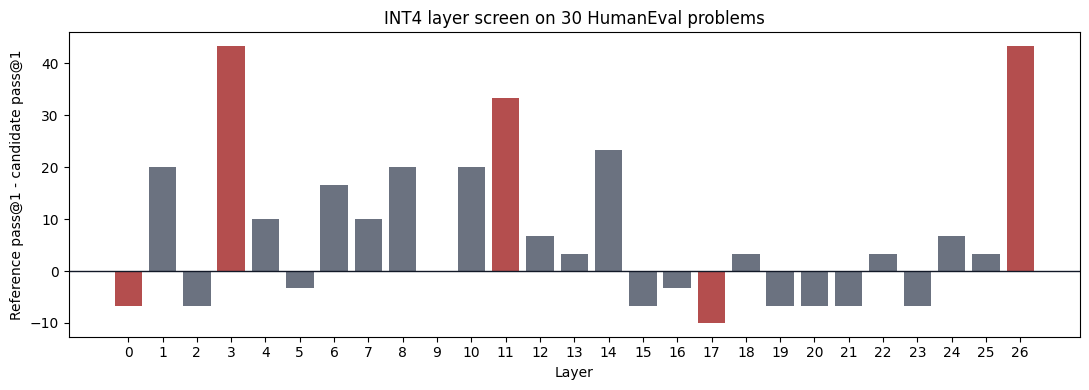

In [22]:
screen_by_layer = sorted(screening_rows, key=lambda row: row["layer_idx"])
selected_layers = set(SELECTED_FOLLOWUP_LAYERS if "SELECTED_FOLLOWUP_LAYERS" in globals() else [])

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#b44e4e" if row["layer_idx"] in selected_layers else "#6b7280" for row in screen_by_layer]
ax.bar(
    [row["layer_idx"] for row in screen_by_layer],
    [row["delta_pass_at_1_percent"] for row in screen_by_layer],
    color=colors,
)
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("INT4 layer screen on 30 HumanEval problems")
ax.set_xlabel("Layer")
ax.set_ylabel("Reference pass@1 - candidate pass@1")
ax.set_xticks([row["layer_idx"] for row in screen_by_layer])
plt.tight_layout()
plt.show()

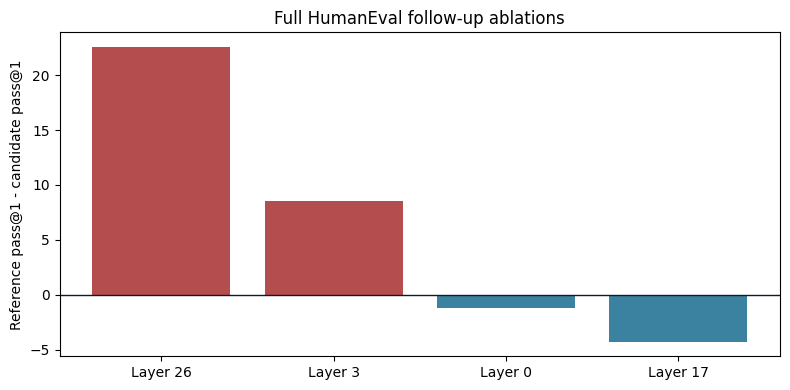

In [23]:
if full_comparison_rows:
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ["#b44e4e" if row["delta_pass_at_1_percent"] > 5 else "#3b82a0" for row in full_comparison_rows]
    labels = [f"Layer {row['layer_idx']}" for row in full_comparison_rows]
    values = [row["delta_pass_at_1_percent"] for row in full_comparison_rows]

    ax.bar(labels, values, color=colors)
    ax.axhline(0, color="#111827", linewidth=1)
    ax.set_title("Full HumanEval follow-up ablations")
    ax.set_ylabel("Reference pass@1 - candidate pass@1")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No full follow-up rows available yet.")

## 10. Conclusions

The final conclusion is generated from saved artifacts, not from the experiment variables above.

In [24]:
def row_for_layer(rows, layer_idx):
    for row in rows:
        if row["layer_idx"] == layer_idx:
            return row
    return None


def screen_row_for_layer(rows, layer_idx):
    for row in rows:
        if row["layer_idx"] == layer_idx:
            return row
    return None


def full_layer_sentence(layer_idx, label):
    row = row_for_layer(full_comparison_rows, layer_idx)
    if row is None:
        screen_row = screen_row_for_layer(screening_rows, layer_idx)
        if screen_row is None:
            return f"- Layer {layer_idx}: no saved screen or full follow-up result found."
        return (
            f"- Layer {layer_idx}: screen delta {screen_row['delta_pass_at_1_percent']:.2f} points; "
            "full follow-up is not yet saved."
        )
    return (
        f"- Layer {layer_idx} ({label}): full delta {row['delta_pass_at_1_percent']:.2f} points "
        f"({row['candidate_n_passed']}/{row['n_total']} passed)."
    )

conclusion_lines = [
    f"Baseline artifact: {baseline_artifact_from_disk['evaluation']['n_passed']}/"
    f"{baseline_artifact_from_disk['evaluation']['n_total']} = "
    f"{baseline_artifact_from_disk['evaluation']['pass_at_1_percent']:.2f}% pass@1.",
    full_layer_sentence(26, "sensitive"),
    full_layer_sentence(3, "sensitive"),
    full_layer_sentence(11, "screen hit to retest"),
    full_layer_sentence(0, "control"),
    full_layer_sentence(17, "control"),
    "Notebook 08 should protect layers 26 and 3, keep layer 11 on the retest/protect list until full data exists, and use layers 0 and 17 as candidates for lower precision first.",
]

display(Markdown("\n".join(conclusion_lines)))

Baseline artifact: 115/164 = 70.12% pass@1.
- Layer 26 (sensitive): full delta 22.56 points (78/164 passed).
- Layer 3 (sensitive): full delta 8.54 points (101/164 passed).
- Layer 11: screen delta 33.33 points; full follow-up is not yet saved.
- Layer 0 (control): full delta -1.22 points (117/164 passed).
- Layer 17 (control): full delta -4.27 points (122/164 passed).
Notebook 08 should protect layers 26 and 3, keep layer 11 on the retest/protect list until full data exists, and use layers 0 and 17 as candidates for lower precision first.

## 11. Memory Cleanup

Run the final cell after the model-backed experiment cells are finished. The artifact-analysis cells above do not need the model in memory.

In [25]:
def model_memory_cleanup():
    large_names = [
        "model",
        "tokenizer",
        "config",
        "HUMANEVAL",
        "smoke_result",
        "baseline_artifact",
        "screening_artifact",
        "followup_artifact",
    ]

    for name in large_names:
        if name in globals():
            del globals()[name]

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        try:
            torch.mps.empty_cache()
        except AttributeError:
            pass

    print("Deleted large notebook objects and requested Python/accelerator memory cleanup.")

# model_memory_cleanup()